<a href="https://colab.research.google.com/github/suhaasteja/VOD_reviewer/blob/main/VOD_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Clash Royale VOD Reviewer 👑

Clash Royale is a fast-paced competitive mobile game where players deploy troops
to destroy the opponent's towers — whoever captures the most towers before the
clock runs out wins.

**What's a VOD?**
VOD stands for *Video on Demand* — in gaming, it refers to a recorded replay of
a match. Reviewing your own VODs is one of the most effective ways to improve:
you see your decisions from the outside, spot patterns you missed in the moment,
and identify exactly where a game was won or lost. Pro players and coaches do
this constantly. The problem is it's time-consuming and requires a trained eye.

**Where Perceptron comes in**
This notebook uses Perceptron Mk1 — a vision model that understands video — to
automate that review process. Instead of scrubbing through footage manually, you
ask a question in plain English and get a grounded, timestamped answer backed by
what the model actually saw on screen. No transcripts, no audio analysis, no
game-specific training data — pure visual reasoning on the gameplay footage itself.

The final 30 seconds are where matches are decided. That's the window we focus on.

**What it does:**
- **VOD analysis** — reviews the last 30s of a match and diagnoses the single
  defining play: the outplay that secured the win, or the mistake that cost the loss
- **Card tracking** — upload a reference image of any troop card and the model
  will track how many times it was deployed and the damage it dealt (powered by
  in-context learning — no retraining required)

In [ ]:
%pip install --upgrade perceptron --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 2.3 MB/s eta 0:00:00


## Step 1 — Load the gameplay clip

We download a sample 30-second Clash Royale clip from the repo directly into
the Colab runtime. To use your own footage, replace `VIDEO_URL` with a link to
your video or upload a file and update `VIDEO_PATH` accordingly.

> **Note:** Perceptron Mk1 processes video at 2fps and caps at ~128 seconds per
> API call. A 30-second clip is ideal — it fits in a single call with no
> preprocessing required.

In [ ]:
VIDEO_URL = "https://raw.githubusercontent.com/suhaasteja/VOD_reviewer/main/content/clash-royale_last_30s.mp4"
### make sure your video is < 20mb
!curl -L -so last_30_s.mp4 {VIDEO_URL}

### Preview — final 30 seconds

The clip below is the window Mk1 will analyze. Watch it once before running
the analysis — it helps you validate the model's output against what you saw.

<video src="https://raw.githubusercontent.com/suhaasteja/VOD_reviewer/main/content/clash-royale_last_30s.mp4" controls width="200" muted loop>
  Your browser doesn't support the video tag.
</video>

## Step 2 — Configure Perceptron

Set your API key in Colab's **Secrets** panel (the 🔑 icon in the left sidebar)
under the name `PERCEPTRON_API_KEY`. The cell below reads it securely and
initialises the Mk1 client.

Don't have a key yet? Get one at [perceptron.inc](https://platform.perceptron.inc/).

In [ ]:
import os
from google.colab import userdata

from perceptron import configure, question, video, image, perceive, text


api_key = userdata.get('PERCEPTRON_API_KEY')
if not api_key or api_key.startswith("<"):
    raise RuntimeError("Set PERCEPTRON_API_KEY or replace the placeholder in this cell.")

configure(
    provider="perceptron",
    model="perceptron-mk1",
    api_key=api_key,
)

VIDEO_PATH = "last_30_s.mp4"

## Step 3 — VOD analysis

The prompt below is the core of the review. It instructs Mk1 to:
1. Determine the match outcome from the visual game state (winner screen, tower counts)
2. Branch its analysis — diagnosing the decisive mistake on a loss, or surfacing
   hidden inefficiencies on a win

You can customise this prompt for any game or analysis style. The model reads
the gameplay visually — no audio, no OCR workaround, no game-specific training.

In [ ]:
VOD_PROMPT = """Analyze these final 30 seconds of Clash Royale gameplay. Evaluate my performance based on whether this clip is a win or a loss:

- IF A LOSS: Diagnose the single defining mistake that cost me the match. Evaluate my win-condition targeting, elixir/cycle management, and card placement. Suggest the exact alternative card sequence that would have secured a win or tie.
- IF A WIN: Identify the key outplay or macro decision that secured the victory. Spot any hidden inefficiencies, resource mismanagement, or structural vulnerabilities I still committed despite winning.

"""

In [ ]:
QUESTION = VOD_PROMPT

result = question(video(VIDEO_PATH), QUESTION, reasoning=True, expects="clip")

print("--- Reasoning ---")
print(result.reasoning or "(none)")
print("\n--- Answer ---")
print(result.text)

--- Reasoning ---
So, let's analyze this Clash Royale clip. First, check if it's a win or loss. The video shows "Match Over!" and then the winner screen with "Suhass" as the winner (since the blue side is Suhass, and the crown is on their side). So it's a win.

Now, identify the key outplay or macro decision. Let's look at the gameplay:

- The player (Suhass) is on the blue side. The opponent (juao) is red.
- In the final seconds, the opponent's king tower is still up, but the player's towers are holding. Wait, no—wait, the match ends with the player winning, so the opponent's towers must have been destroyed.

Looking at the timeline: The timer counts down, and at the end, "Match Over!" appears, then the winner screen shows Suhass as winner. So the player won.

Key outplay: Let's see the card plays. The player uses a combination of troops and spells. For example, in the later part, maybe a well-timed spell or troop placement that prevented the opponent from pushing.

Wait, the opponent

## Step 4 — Card-level tracking with in-context learning

Standard vision models need to be retrained to recognise new objects. Mk1
doesn't — you can show it a reference image at query time and it will track
that object throughout the video.

Here we upload a single screenshot of the **Hog Rider** card and ask Mk1 to
count deployments and measure tower damage across the clip. Swap in any card
image to track a different troop — no code changes needed.

This is Perceptron's **in-context learning** capability: the reference image
is passed as part of the prompt, not baked into the model.

In [ ]:
EXAMPLE_IMAGE = "https://raw.githubusercontent.com/suhaasteja/VOD_reviewer/main/content/hog-rider-on-field.jpg"

!curl -L -so hog-rider-on-field.jpg {EXAMPLE_IMAGE}

In [ ]:
EXAMPLE_IMAGE="hog-rider-on-field.jpg"
QUERY_VIDEO="last_30_s.mp4"

### Reference image — Hog Rider

This is the image we pass to Mk1 as the visual example. The model uses it to
identify the Hog Rider in the gameplay footage, even though it has never been
explicitly trained on Clash Royale card art.

<img src="https://raw.githubusercontent.com/suhaasteja/VOD_reviewer/main/content/hog-rider-on-field.jpg" width="100" alt="Hog Rider">

In [ ]:
@perceive(reasoning=True, expects="clip")
def check_card_info(example_image_path: str, query_video_path: str):
    return (
        image(example_image_path)
        + text("this card is called hog-rider from a game called clash royale")
        + video(query_video_path)
        + text("how many times was it played and how much opponents tower health amount did it reduce?")
    )

result = check_card_info(EXAMPLE_IMAGE, QUERY_VIDEO)

print("--- Reasoning ---")
print(result.reasoning or "(none)")
print("\n--- Answer ---")
print(result.text)

--- Reasoning ---
So, let's look at the video. First, the Hog Rider is played once in the gameplay. Now, check the opponent's tower health. The opponent's tower (the one with the red crown) starts with some health. Let's see the numbers. In the video, when the Hog Rider attacks, the tower's health goes from 1274 to 843. Wait, let's calculate the reduction: 1274 - 843 = 431. So the Hog Rider was played once, and it reduced the opponent's tower health by 431.

--- Answer ---
To determine how many times the Hog Rider was played and the health reduction on the opponent’s tower:  

1. **Number of times played**: In the video, the Hog Rider is deployed *once* during the match (visible as the character is placed on the battlefield).  

2. **Opponent’s tower health reduction**:  
   - The opponent’s tower (top - red - crowned structure) starts with a health value of **1274** (seen early in the gameplay).  
   - After the Hog Rider’s attack, the tower’s health drops to **843** (visible later in

todo
- add observability (langfuse)
- generate clips for multiple cards
- generate structured output for analytics
- use LLM as tool / use mk1 as a tool (read docs)

In [31]:
import os

CARDS = [
    {"name": "hog-rider",     "image": "hog-rider-on-field.jpg",  "url": "https://raw.githubusercontent.com/suhaasteja/VOD_reviewer/main/content/hog-rider-on-field.jpg"},
    {"name": "witch",         "image": "witch.png",               "url": "https://raw.githubusercontent.com/suhaasteja/VOD_reviewer/main/content/witch.png"},
    {"name": "giant-skeleton","image": "giant-skeleton.png",      "url": "https://raw.githubusercontent.com/suhaasteja/VOD_reviewer/main/content/giant-skeleton.png"},
    {"name": "knight",        "image": "knight.png",              "url": "https://raw.githubusercontent.com/suhaasteja/VOD_reviewer/main/content/knight.png"},
    {"name": "little-prince", "image": "little-prince.png",       "url": "https://raw.githubusercontent.com/suhaasteja/VOD_reviewer/main/content/little-prince.png"},
]

# Download all card images
for card in CARDS:
    if not os.path.exists(card["image"]):
        os.system(f"curl -L -so {card['image']} {card['url']}")
        print(f"✓ downloaded {card['name']}")
    else:
        print(f"  skipped {card['name']} (already exists)")

print("\nAll card images ready.")

  skipped hog-rider (already exists)
✓ downloaded witch
✓ downloaded giant-skeleton
✓ downloaded knight
✓ downloaded little-prince

All card images ready.


In [91]:
from pydantic import BaseModel, Field
from typing import Literal

class CardVODResult(BaseModel):
    """VOD essentials — only what a coach would actually review."""

    times_played: int = Field(
        description="Count how many times this card appears being placed on the battlefield. Watch for the deploy animation."
    )

    use_type: Literal["offensive", "defensive", "mixed"] = Field(
        description="offensive = placed in the enemy's half of the map (across the river). defensive = placed in the player's own half. mixed = started defensive but crossed the river during the clip."
    )

    dominant_lane: Literal["left", "right", "mixed", "unknown"] = Field(
        description="Which side of the map was this card used on most? left = left tower lane, right = right tower lane, mixed = both lanes equally."
    )

    elixir_trade: Literal["positive", "negative", "neutral", "unknown"] = Field(
        description="Compare what this card cost vs what the opponent spent to counter it. positive = opponent spent more elixir to stop it (good trade). negative = opponent spent less elixir to stop it (bad trade). neutral = roughly equal. unknown = couldn't observe the counter."
    )

    reached_tower: bool = Field(
        description="True only if this card physically touched or attacked an enemy tower. False if it was destroyed before reaching a tower or used purely defensively."
    )

    win_or_loss: Literal["win", "loss", "unknown"] = Field(
        description="Read the winner screen at the end of the clip. If player's name or crown is highlighted — win. If opponent's — loss. unknown if the clip ends before the match concludes."
    )

    coaching_note: str = Field(
        description="One specific, actionable sentence a Clash Royale coach would say about this card's role in the clip. Mention the lane, what it did, and whether it helped or hurt. e.g. 'Hog Rider pushed left lane unchallenged and chipped the tower — strong cycle pressure that contributed to the win.'"
    )

    confidence: float = Field(
        description="How clearly could you see and track this card throughout the clip? 1.0 = perfectly visible the whole time. 0.5 = partially obscured or hard to distinguish from other troops. 0.0 = barely visible."
    )

In [92]:
def analyze_card(card: dict, video_path: str) -> dict:

    # call 1 — structured stats
    @perceive(
    reasoning=True,
    response_format=pydantic_format(CardVODResult, strict=True)
    )
    def get_stats(img_path: str, vid_path: str):
        return (
            image(img_path)
            + text(f"This card is called {card['name']} from Clash Royale.")
            + video(vid_path)
            + text("""
            Track this card throughout the video.

            First determine use_type: if the card was deployed and stayed in the player's
            own half of the map (behind the river), it is defensive — set tower_damage and
            tower_damage_calculation to null immediately, do not attempt to measure damage.

            Only calculate tower damage if the card crossed into the enemy half and made
            contact with a tower. Read HP before and after from the health bar numbers
            on screen. Never use game knowledge about card stats.
            """)
      )

    # call 2 — clips only
    @perceive(
        reasoning=False,
        expects="clip"
    )
    def get_clips(img_path: str, vid_path: str):
        return (
            image(img_path)
            + text(f"This card is called {card['name']} from Clash Royale.")
            + video(vid_path)
            + text("Return a clip for every moment this card is deployed on the battlefield. Use the <clip> tag for each deployment.")
        )

    stats_result = get_stats(card["image"], video_path)
    clips_result = get_clips(card["image"], video_path)

    return {
        "card":  card["name"],
        "data":  CardVODResult.model_validate_json(stats_result.text),
        "clips": clips_result.clips or [],
    }

In [93]:
from tqdm.notebook import tqdm
import concurrent.futures
from functools import partial

runner = partial(analyze_card, video_path=QUERY_VIDEO)

results = []
with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
    futures = {executor.submit(runner, card): card for card in CARDS}

    with tqdm(total=len(CARDS), desc="Analyzing cards", unit="card") as pbar:
        for future in concurrent.futures.as_completed(futures):
            card = futures[future]
            try:
                results.append(future.result())
                pbar.set_postfix(last=card["name"])
            except Exception as e:
                print(f"✗ {card['name']} failed: {e}")
            pbar.update(1)

# sort back to original CARDS order since as_completed is non-deterministic
results.sort(key=lambda r: [c["name"] for c in CARDS].index(r["card"]))

Analyzing cards:   0%|          | 0/5 [00:00<?, ?card/s]


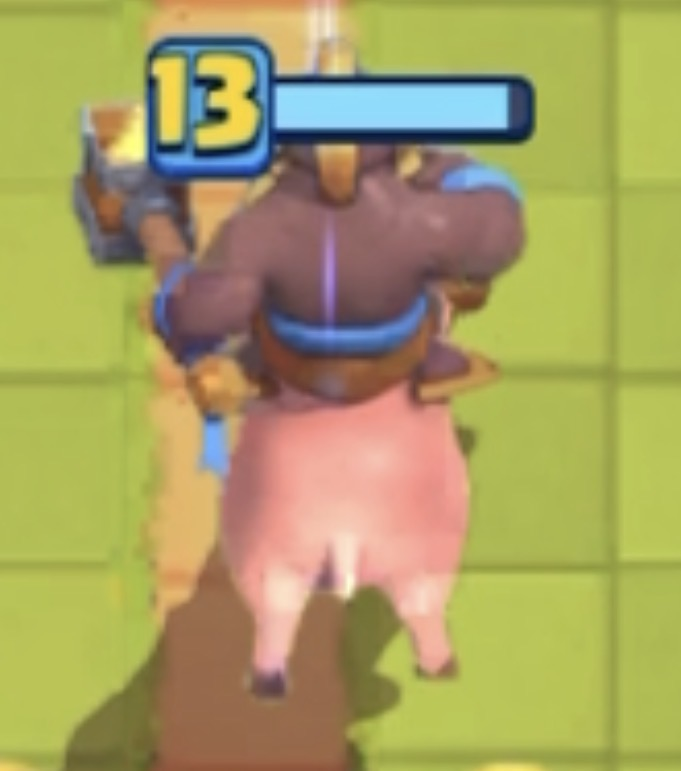


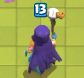


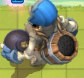


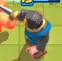


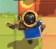

In [95]:
import base64
from IPython.display import display, HTML

def img_to_base64(path: str) -> str:
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()

for r in results:
    d    = r["data"]
    card = next(c for c in CARDS if c["name"] == r["card"])
    b64  = img_to_base64(card["image"])
    ext  = card["image"].split(".")[-1]

    clip_rows = ""
    for c in r["clips"]:
        window = f"{c.timestamp.at:.2f}s → {c.timestamp.until:.2f}s" if c.timestamp.until else f"{c.timestamp.at:.2f}s"
        clip_rows += f"<li>{window} — {c.mention or '(no label)'}</li>"

    display(HTML(f"""
    <div style='display:flex;gap:12px;padding:10px;border-bottom:1px solid #333;'>
      <img src='data:image/{ext};base64,{b64}' style='object-fit:contain;width:120px;border-radius:6px;'/>
      <div style='font-size:13px;color:#eee;line-height:2;'>
        <b>{r['card'].upper()}</b><br>
        🎯 {d.times_played}x &nbsp;|&nbsp; {d.use_type} &nbsp;|&nbsp; {d.dominant_lane} lane &nbsp;|&nbsp;
        ⚡ {d.elixir_trade} &nbsp;|&nbsp; 🏆 {d.win_or_loss} &nbsp;|&nbsp;
        🏰 {"hit tower" if d.reached_tower else "no tower"}<br>
        <i style='color:#aaa;'>💬 {d.coaching_note}</i><br>
        {"<ul style='margin:2px 0;color:#888;font-size:12px;'>" + clip_rows + "</ul>" if clip_rows else ""}
      </div>
    </div>
    """))